## Day 5 — Tuning, Evaluation & Sprint Review

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [18]:
df = pd.read_csv('/content/kc_house_data.csv')

In [20]:
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [21]:
df.drop(columns=['id','date'], inplace=True)

In [28]:
numeric_cols = df.select_dtypes(include='number').columns


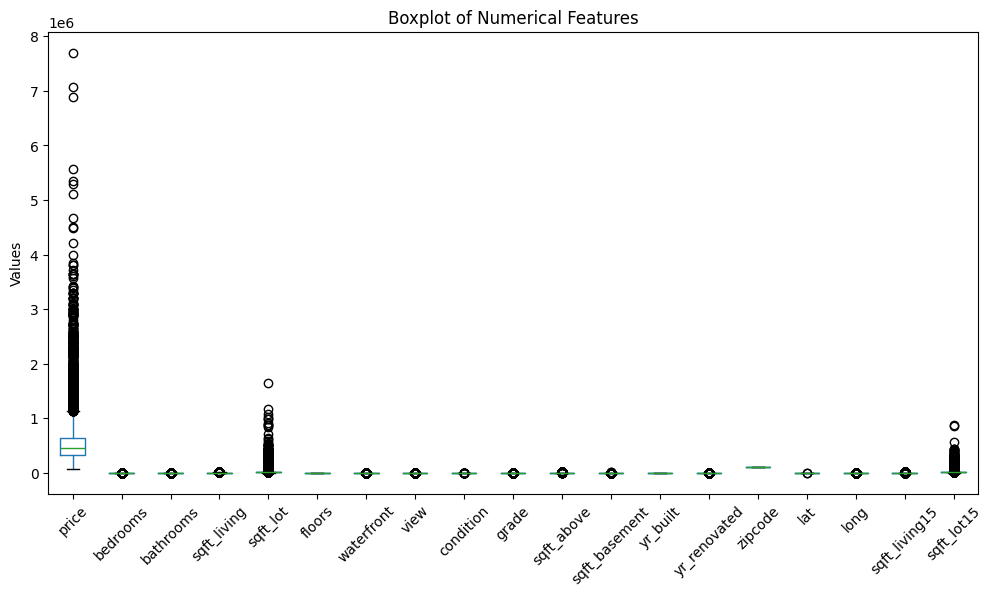

In [29]:
# Select numerical columns


plt.figure(figsize=(12, 6))

df[numeric_cols].boxplot()

plt.title("Boxplot of Numerical Features")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.grid(False)

plt.show()

In [30]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## Exploratory Data Analysis: Numerical Features

The dataset contains **21,613 observations and 21 columns**. The numerical features were examined using descriptive statistics and boxplots to understand their distributions and identify potential outliers.

### Descriptive Statistics

The target variable, `price`, has a mean of approximately **$540,088** and a median of **$450,000**. The difference between the mean and median suggests that the price distribution is right-skewed.

The main property features show the following patterns:

- `bedrooms` has a mean of **3.37**, with values ranging from 0 to 33.
- `bathrooms` has a mean of **2.11**, ranging from 0 to 8.
- `sqft_living` has a mean of approximately **2,080 sq ft**, with a maximum of 13,540 sq ft.
- `sqft_lot` is highly variable, with a mean of approximately **15,107 sq ft** and a maximum of **1,651,359 sq ft**.
- `yr_built` ranges from **1900 to 2015**, while `yr_renovated` contains many zero values, indicating properties that were not renovated.
- `sqft_living15` and `sqft_lot15` also show substantial variation.

### Outlier Analysis

The boxplot shows several potential outliers, particularly in:

- `price`
- `sqft_living`
- `sqft_lot`
- `sqft_living15`
- `sqft_lot15`

These observations are not automatically removed because they may represent genuine large or expensive properties rather than errors.

The large differences in scale between features also show why **feature scaling will be important before training the neural network**.

Overall, the dataset contains sufficient observations and useful numerical features for building a regression model to predict house prices.

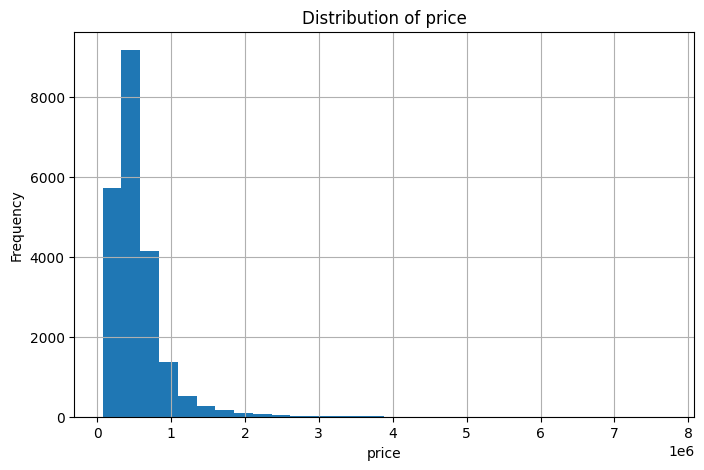

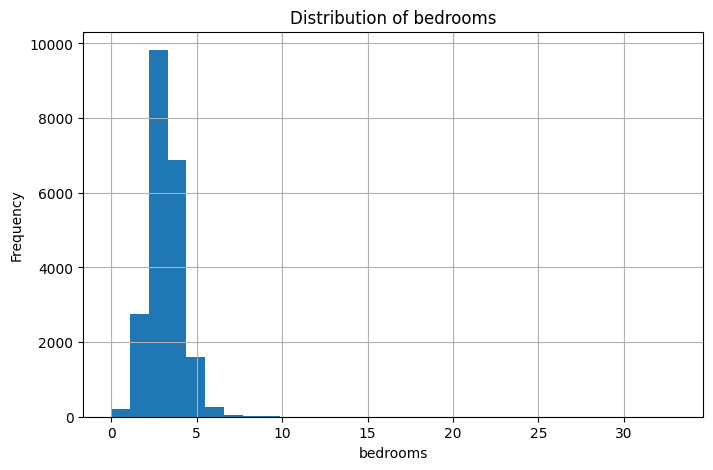

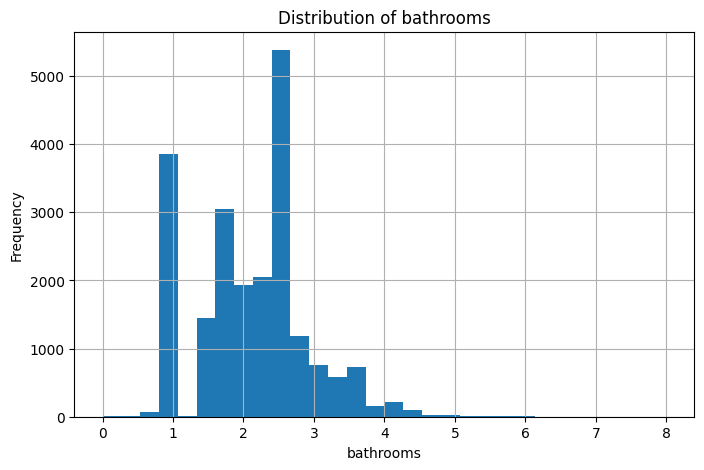

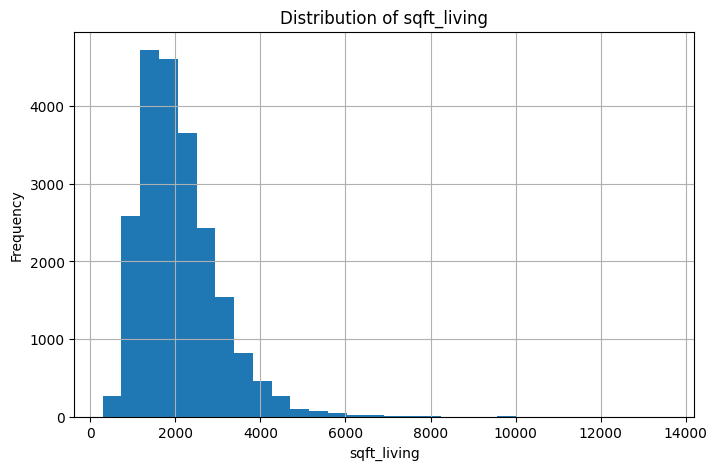

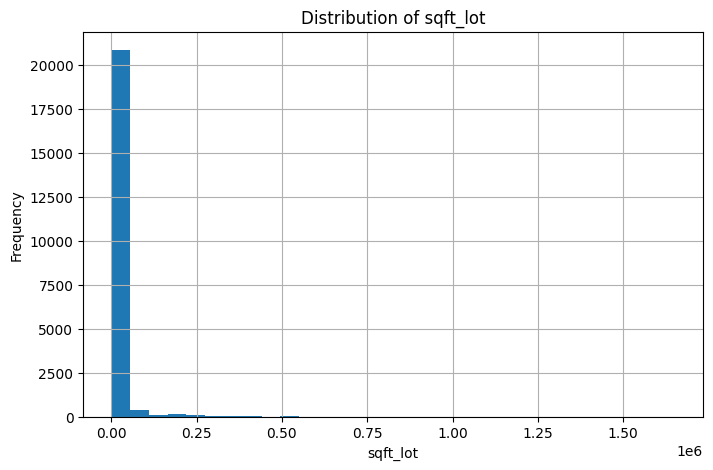

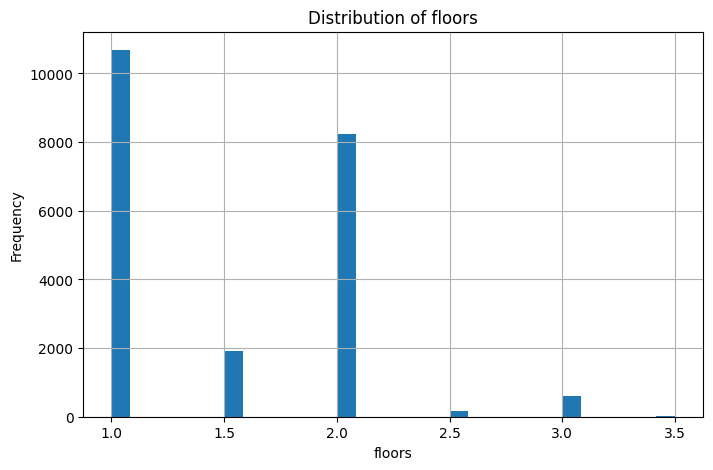

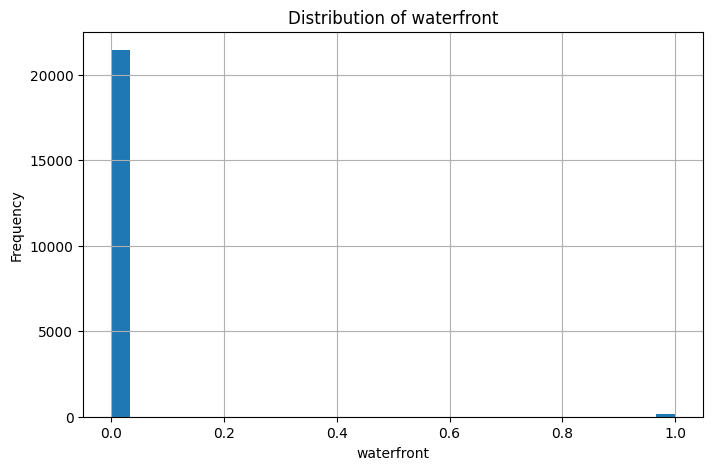

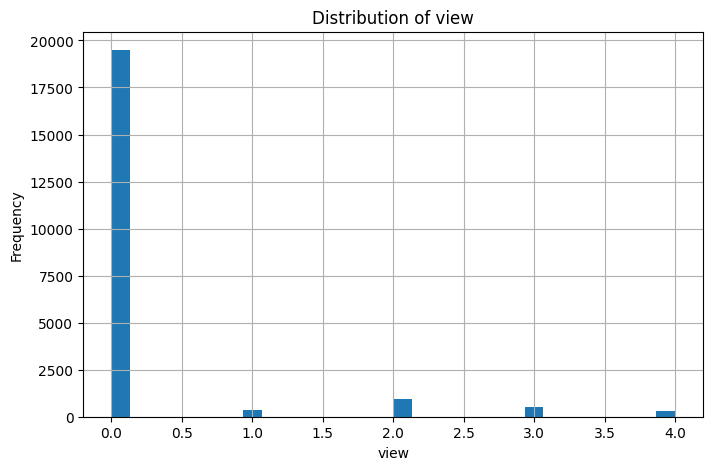

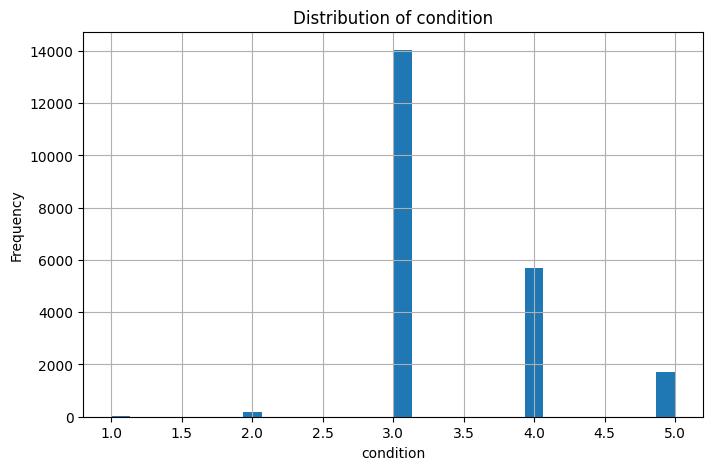

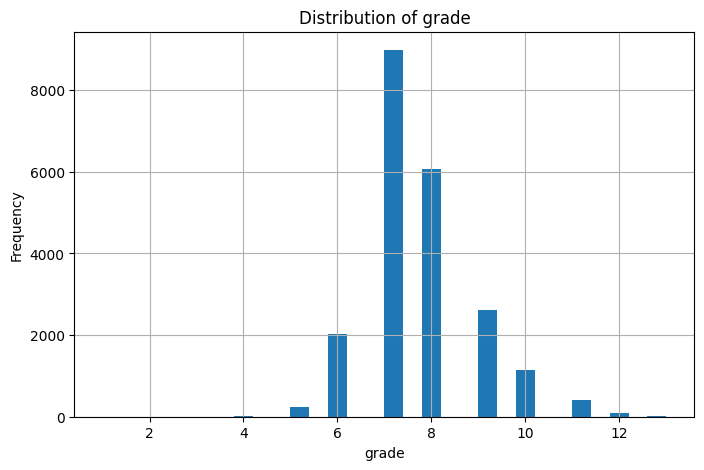

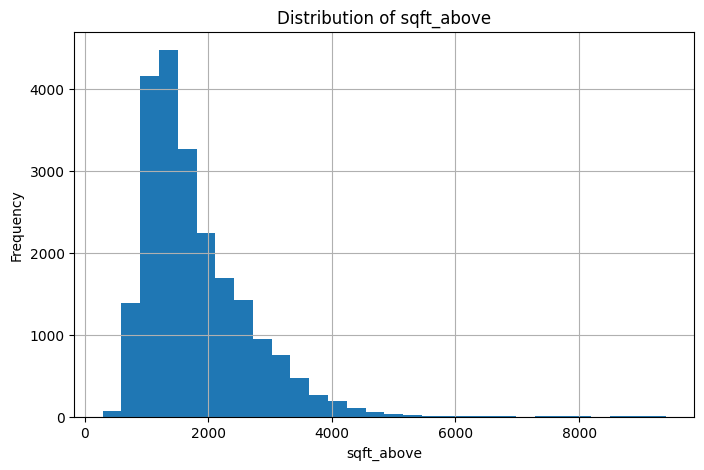

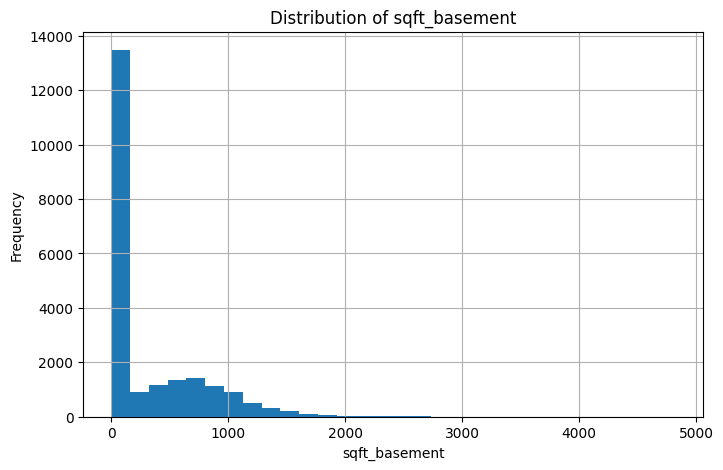

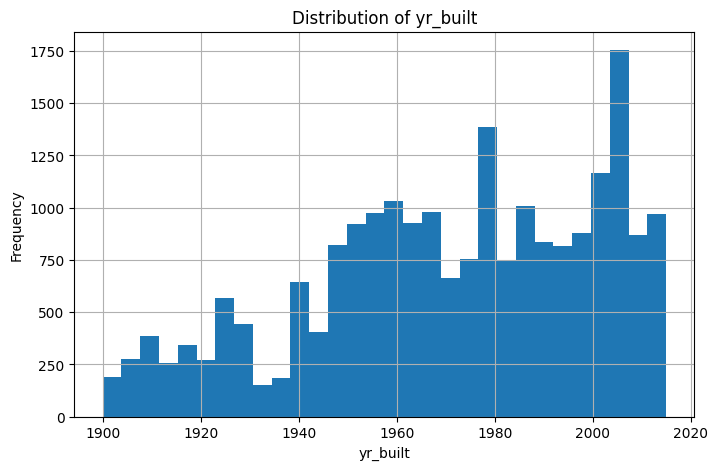

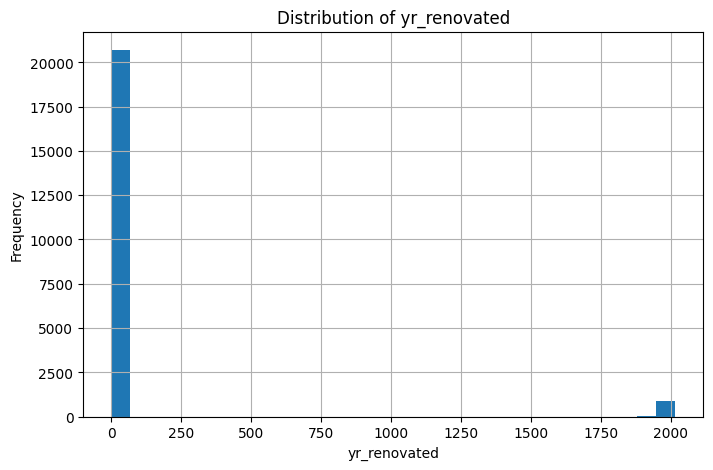

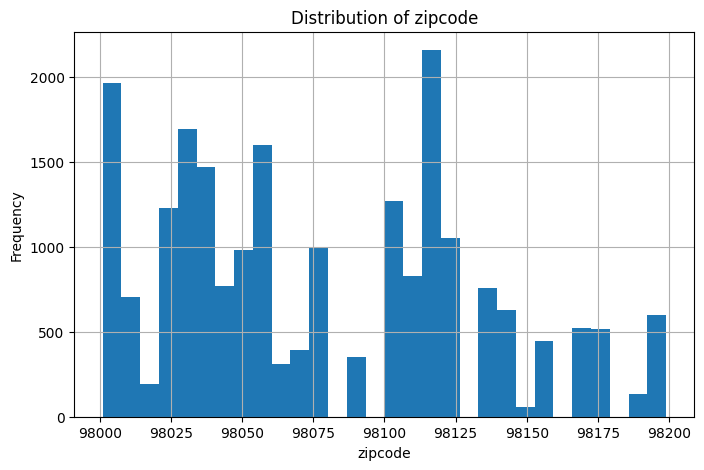

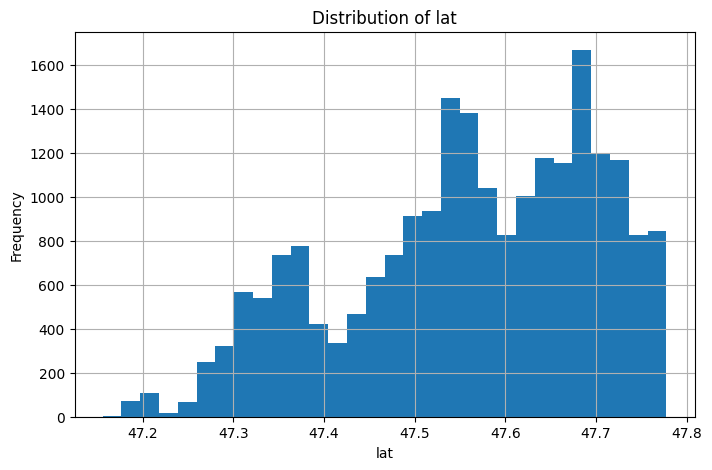

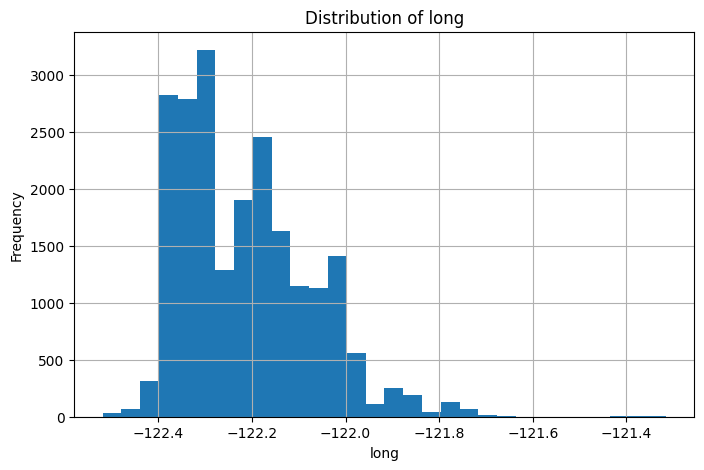

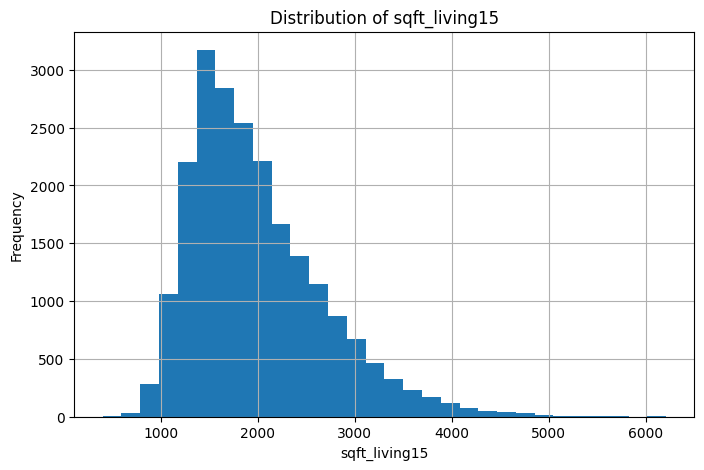

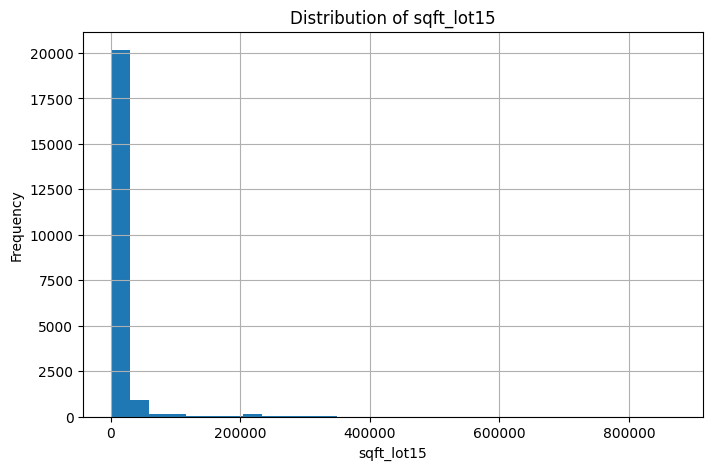

In [31]:
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(df[col], bins=30)

    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.grid(True)
    plt.show()

In [32]:
df.isnull().sum()

,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0
grade,0


## Sprint 1 Planning

### Sprint Goal

The main goal of Sprint 1 is to understand the car price dataset, complete the initial data preprocessing, and establish a baseline regression model that can be used for comparison with the neural network.

### Initial Backlog Tasks

1. **Dataset Selection and Understanding**
   - Load and inspect the car price dataset.
   - Identify numerical and categorical features.
   - Check for missing values and potential outliers.

2. **Data Preprocessing**
   - Handle missing values.
   - Encode categorical features.
   - Scale numerical features.
   - Split the data into training, validation, and test sets.

3. **Baseline Model**
   - Build a simple regression baseline using `DummyRegressor`.
   - Evaluate it using MAE, RMSE, and R².
   - Record the baseline results.

4. **Neural Network Baseline**
   - Build a Keras neural network for regression.
   - Train it using the training and validation sets.
   - Compare its performance with the baseline model.

### Acceptance Criteria

- The dataset is loaded and inspected successfully.
- Preprocessing is completed without data leakage.
- A baseline regression model is trained and evaluated.
- MAE, RMSE, and R² are recorded.
- The neural network can be trained and evaluated.
- All results are documented in the notebook.

In [33]:
# Drop ID, date, and target
X = df.drop(columns=['price'])
y = df['price']

# Numerical columns
numeric_cols = X.columns.tolist()

# Numerical pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols)
])

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Train shape:", X_train_processed.shape)
print("Validation shape:", X_val_processed.shape)
print("Test shape:", X_test_processed.shape)

Train shape: (12967, 18)
Validation shape: (4323, 18)
Test shape: (4323, 18)


### Baseline: LinearRegression

In [34]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Baseline model
baseline = DummyRegressor(strategy="mean")

# Train baseline
baseline.fit(X_train_processed, y_train)

# Predictions
baseline_pred = baseline.predict(X_test_processed)

# Evaluation
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline Results")
print("----------------")
print(f"MAE:  {baseline_mae:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"R²:   {baseline_r2:.4f}")

Baseline Results
----------------
MAE:  242663.5953
RMSE: 410080.4851
R²:   -0.0009


### Baseline Results

A `DummyRegressor` using the mean strategy was used as the baseline model.

The baseline achieved an MAE of **242,663.5953**, an RMSE of **410,080.4851**, and an R² score of **-0.0009**.

The baseline predicts the mean `price` for every observation, so it provides a simple reference point rather than a meaningful predictive model.

The neural network will be compared against this baseline. A successful neural network should achieve lower MAE and RMSE and a higher R² score.

The negative R² score indicates that the baseline performs slightly worse than simply using the mean as a reference, which is expected for a `DummyRegressor`.

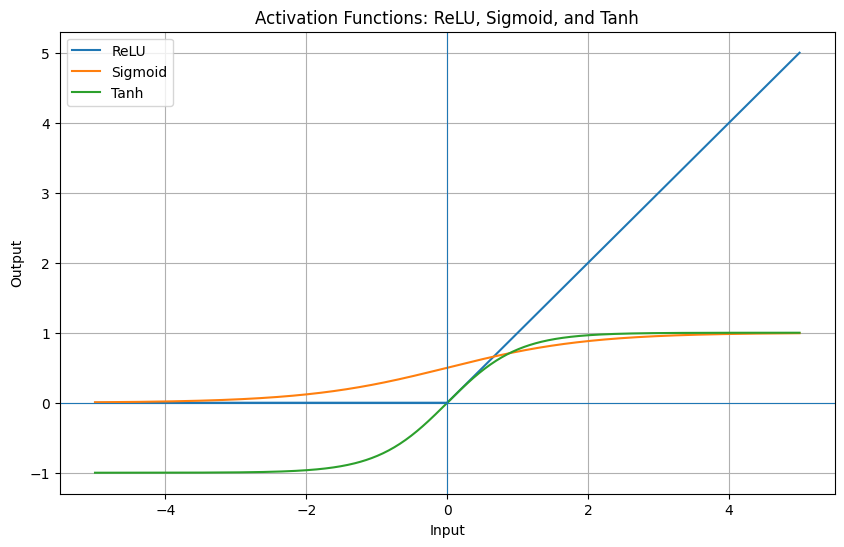

In [35]:
# Range of inputs
x = np.linspace(-5, 5, 500)

# Activation functions
relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(x, relu, label='ReLU')
plt.plot(x, sigmoid, label='Sigmoid')
plt.plot(x, tanh, label='Tanh')

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Activation Functions: ReLU, Sigmoid, and Tanh')
plt.legend()
plt.grid(True)

plt.show()

### Activation Functions

The plot compares three commonly used activation functions: ReLU, Sigmoid, and Tanh.

- **ReLU:** Outputs 0 for negative inputs and keeps positive inputs unchanged. It is commonly used in hidden layers of neural networks.
- **Sigmoid:** Converts inputs into values between 0 and 1, making it suitable for binary classification output layers.
- **Tanh:** Converts inputs into values between -1 and 1 and is centered around zero.

For this project, **ReLU** is used in the hidden layers, while the final output layer for the regression task uses **no activation function** (`Dense(1)`).

### Output Activation and Loss Function

Since the Phase 3 project is a **regression task** where the goal is to predict a continuous house price, the output layer should use **no activation function**.

The final layer is:

`Dense(1)`

The single neuron produces a continuous numerical value representing the predicted house price. No activation is used because the model needs to be able to predict values across the full range of possible prices.

For the loss function, **Mean Squared Error (MSE)** is appropriate:

`loss="mse"`

MSE measures the average squared difference between the actual and predicted prices. Squaring the errors gives larger errors more weight, which encourages the neural network to reduce large prediction errors.

Therefore, the configuration is:

- **Task:** Regression
- **Output layer:** `Dense(1)`
- **Output activation:** None (linear)
- **Loss function:** Mean Squared Error (MSE)

This differs from binary classification, where a sigmoid activation and binary cross-entropy would be used. Since the target here is a continuous `price`, a linear output with MSE is the appropriate choice.

In [36]:
# Sample input
x = np.array([[2.0, 3.0]])

# Layer 1 weights and bias
W1 = np.array([
    [0.5, 0.2, 0.1],
    [0.4, 0.3, 0.6]
])

b1 = np.array([[0.1, 0.2, 0.3]])

# Layer 2 weights and bias
W2 = np.array([
    [0.7],
    [0.5],
    [0.2]
])

b2 = np.array([[0.1]])

# Forward pass - Layer 1
z1 = x @ W1 + b1
a1 = np.maximum(0, z1)  # ReLU

# Forward pass - Layer 2
z2 = a1 @ W2 + b2

# Final output
y_pred = z2

print("Layer 1 pre-activation:", z1)
print("Layer 1 activation:", a1)
print("Final output:", y_pred)

Layer 1 pre-activation: [[2.3 1.5 2.3]]
Layer 1 activation: [[2.3 1.5 2.3]]
Final output: [[2.92]]


### NumPy Forward Pass

A forward pass calculates the output of a neural network from an input without using a deep-learning framework.

The sample input is passed through two layers.

First, the weighted sum is calculated:

`z1 = x @ W1 + b1`

The ReLU activation is then applied:

`a1 = ReLU(z1)`

The activated values are passed to the second layer:

`z2 = a1 @ W2 + b2`

Since this example represents a regression network, the final output uses a **linear activation**, so the prediction is simply:

`y_pred = z2`

This demonstrates the basic process used by neural networks: **input → weighted sum → activation → next layer → prediction**.

### Four-Step Training Loop

**1. Forward Pass**  
Input → Neural Network → Prediction

⬇️

**2. Calculate Loss**  
Prediction ↔ Actual Value → Loss

⬇️

**3. Backpropagation**  
Loss → Calculate Gradients

⬇️

**4. Update Weights**  
Gradients + Adam → Updated Weights

⬇️

**Repeat for the next batch and epoch**

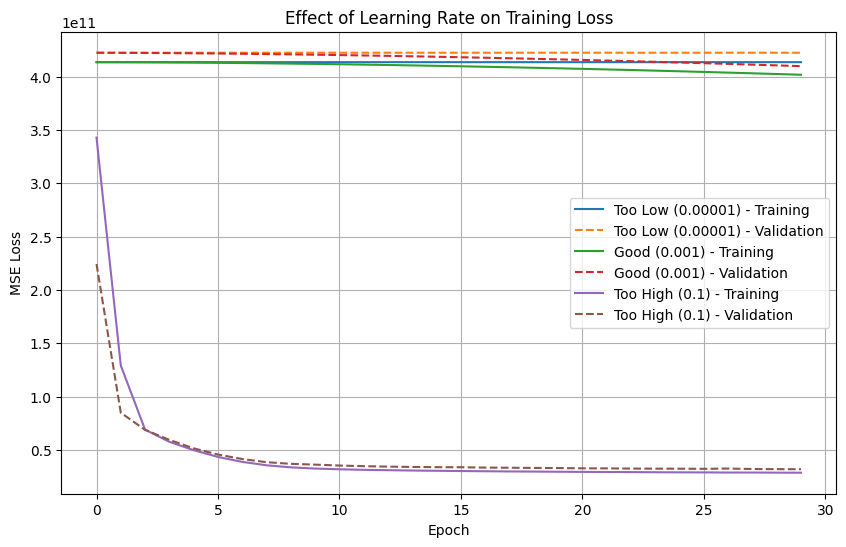

In [38]:
import tensorflow as tf

learning_rates = {
    "Too Low (0.00001)": 0.00001,
    "Good (0.001)": 0.001,
    "Too High (0.1)": 0.1
}

histories = {}

for name, lr in learning_rates.items():

    # Small network
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_processed.shape[1],)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1)
    ])

    # Compile with different learning rate
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="mse"
    )

    # Train
    history = model.fit(
        X_train_processed,
        y_train,
        validation_data=(X_val_processed, y_val),
        epochs=30,
        batch_size=32,
        verbose=0
    )

    histories[name] = history


# Plot loss curves
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        history.history["loss"],
        label=f"{name} - Training"
    )
    plt.plot(
        history.history["val_loss"],
        linestyle="--",
        label=f"{name} - Validation"
    )

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Effect of Learning Rate on Training Loss")
plt.legend()
plt.grid(True)
plt.show()

### Learning Rate Experiment

A small neural network was trained using three different learning rates while keeping the architecture, batch size, number of epochs, and data split fixed.

- **0.00001 (Too Low):** The loss decreases very slowly, indicating that the weight updates are too small for efficient learning.
- **0.001 (Good):** The loss decreases steadily and provides a good balance between learning speed and stability.
- **0.1 (High):** The loss decreases very quickly during the first few epochs and then levels off. In this experiment, it did not show severe instability, but the learning rate is relatively large and may be less reliable with different data or initializations.

Overall, the experiment shows that the learning rate strongly affects how quickly the neural network converges. The learning rate of **0.001** provides a stable learning behavior and is a reasonable choice for this project.

### Backpropagation and the Chain Rule

Backpropagation is the process used by a neural network to determine how much each weight and bias contributed to the prediction error.

After the forward pass, the model calculates the loss by comparing its prediction with the actual target. Backpropagation then works backward through the network and computes the **gradient of the loss with respect to each parameter**. These gradients tell the optimizer how the weights should be adjusted to reduce the loss.

The **chain rule** is involved because the output of one layer becomes the input to the next layer. Therefore, the loss depends on earlier weights indirectly through several intermediate calculations.

For example:

`Weight → Hidden Layer → Output → Loss`

To find how a weight affects the loss, the chain rule combines the derivatives through each step:

`dLoss/dWeight = dLoss/dOutput × dOutput/dHidden × dHidden/dWeight`

This allows the network to efficiently calculate gradients for all its parameters, which are then used by the optimizer, such as Adam, to update the weights.

In simple terms, **backpropagation works backward from the error to determine how each parameter should change, while the chain rule makes it possible to calculate these effects through multiple connected layers.**

In [39]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Number of input features
n_features = X_train_processed.shape[1]

# Build Sequential neural network
model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)  # Linear output for regression
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

### Neural Network Architecture

The Phase 3 project is a **regression task** that predicts a continuous house `price`. Therefore, the network uses a single output neuron with a linear activation.

The network consists of two hidden layers:

- The first `Dense` layer contains **64 neurons** with ReLU activation.
- The second `Dense` layer contains **32 neurons** with ReLU activation.
- The final `Dense(1)` layer produces a single continuous price prediction.

The model has **3,329 trainable parameters** and no non-trainable parameters.

**Architecture:**

Input → Dense(64, ReLU) → Dense(32, ReLU) → Dense(1, Linear)

The final layer does not use an activation function because regression requires an unrestricted continuous output. The model is compiled using **Adam** as the optimizer and **Mean Squared Error (MSE)** as the loss function.

This architecture is appropriate for learning non-linear relationships between the house features and the target house price.

In [40]:
# Compile the model
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Train the model
history = model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 413017079808.0000 - mae: 536846.3125 - val_loss: 420295540736.0000 - val_mae: 538548.8750
Epoch 2/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 405799141376.0000 - mae: 532292.1875 - val_loss: 405437939712.0000 - val_mae: 529254.0625
Epoch 3/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 382419697664.0000 - mae: 517089.0000 - val_loss: 371346931712.0000 - val_mae: 507004.3438
Epoch 4/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 340729528320.0000 - mae: 488218.3438 - val_loss: 320261324800.0000 - val_mae: 470642.3438
Epoch 5/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 285000237056.0000 - mae: 445605.7812 - val_loss: 258384789504.0000 - val_mae: 420007.3125
Epoch 6/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 224318341120.0000 - mae: 390920.1562 - val_loss: 198608928768.0000 - val_mae: 361383.9375
Epoch 7/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 170393812992.0000 - mae: 332801.0625 - v

### Training Results

The neural network was trained for **50 epochs** using the Adam optimizer and Mean Squared Error (MSE) loss.

The training loss decreased from approximately **413.0 billion** in the first epoch to **32.1 billion** by epoch 50. Similarly, the validation loss decreased from approximately **420.3 billion** to **35.6 billion**.

The validation MAE also improved substantially, decreasing from approximately **538,549** to **115,931**.

Both training and validation loss decreased consistently throughout training. The validation loss remained slightly higher than the training loss, which is expected because the model is evaluated on unseen validation data.

There is no clear sign of severe overfitting in these 50 epochs because the validation loss continues to decrease rather than increase. The model may benefit from additional training, although EarlyStopping should be used to automatically stop training when validation performance stops improving.

Overall, the results indicate that the neural network is learning useful patterns for predicting house prices.

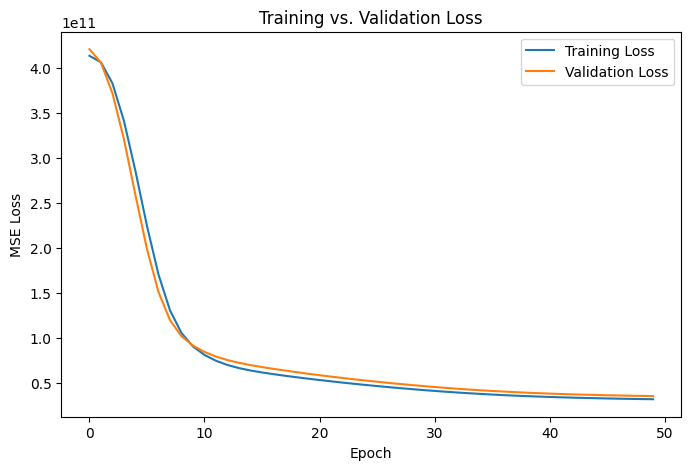

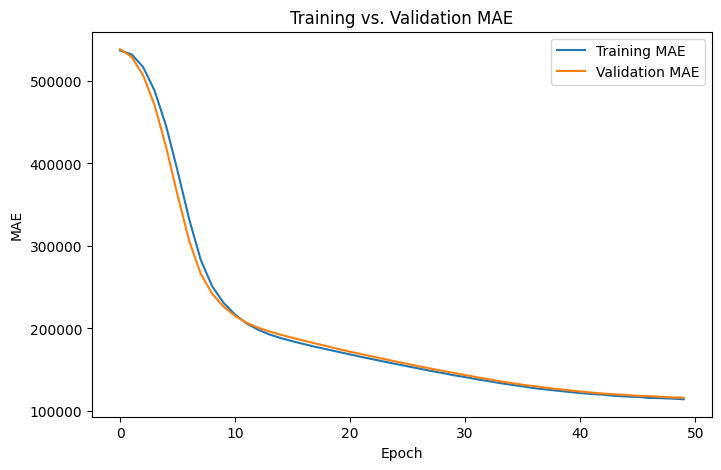

In [41]:
# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.show()


# Plot MAE
plt.figure(figsize=(8, 5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training vs. Validation MAE')
plt.legend()
plt.show()

## Training vs. Validation Performance

The training history was analyzed by comparing the training and validation loss and MAE over 50 epochs.

The loss decreased consistently throughout training, from approximately **413 billion** in the first epoch to **32.1 billion** for training and **35.6 billion** for validation by epoch 50.

Similarly, the MAE decreased from approximately **536,846** to **114,116** on the training set and **115,931** on the validation set.

The training and validation curves follow a similar downward trend, with only a small gap between them. This indicates that the model is learning effectively and does not show severe overfitting during the 50 epochs.

However, the validation loss remains slightly higher than the training loss, which is expected. Since both metrics are still improving at epoch 50, the model may benefit from additional training or from using `EarlyStopping` to automatically select the best epoch.

Overall, the model shows a **good learning pattern with limited overfitting**, although further tuning may improve its predictive performance.

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

regularized_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1)
])

regularized_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

regularized_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
history_regularized = regularized_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 413077012480.0000 - mae: 536874.9375 - val_loss: 420582588416.0000 - val_mae: 538675.3125
Epoch 2/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 407006019584.0000 - mae: 532823.7500 - val_loss: 408172724224.0000 - val_mae: 530532.5000
Epoch 3/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 387204218880.0000 - mae: 519476.9375 - val_loss: 379014709248.0000 - val_mae: 510802.1875
Epoch 4/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 350346412032.0000 - mae: 493138.3750 - val_loss: 332089196544.0000 - val_mae: 476780.8750
Epoch 5/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 298317545472.0000 - mae: 452847.3125 - val_loss: 273877188608.0000 - val_mae: 429360.6250
Epoch 6/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 239974465536.0000 - mae: 400295.9062 - val_loss: 213799256064.0000 - val_mae: 371925.2812
Epoch 7/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 185837387776.0000 - mae: 342969.3750 - v

## Dropout Regularization Comparison

Dropout was added to the neural network to reduce overfitting and improve generalization.

The regularized model uses dropout rates of **0.3** after the first hidden layer and **0.2** after the second hidden layer. The model was trained for 50 epochs using the same training and validation sets as the original model.

The validation loss decreased substantially during training, reaching approximately **37.56 billion** at epoch 50. The validation MAE also decreased to approximately **120,164**.

The training and validation curves remain relatively close, indicating that the model is learning without a severe overfitting problem. Unlike the original model, Dropout adds regularization by randomly disabling a proportion of neurons during training.

Overall, the Dropout model shows strong learning behavior and should be compared with the original model using the same validation and test metrics to determine whether regularization improved generalization.

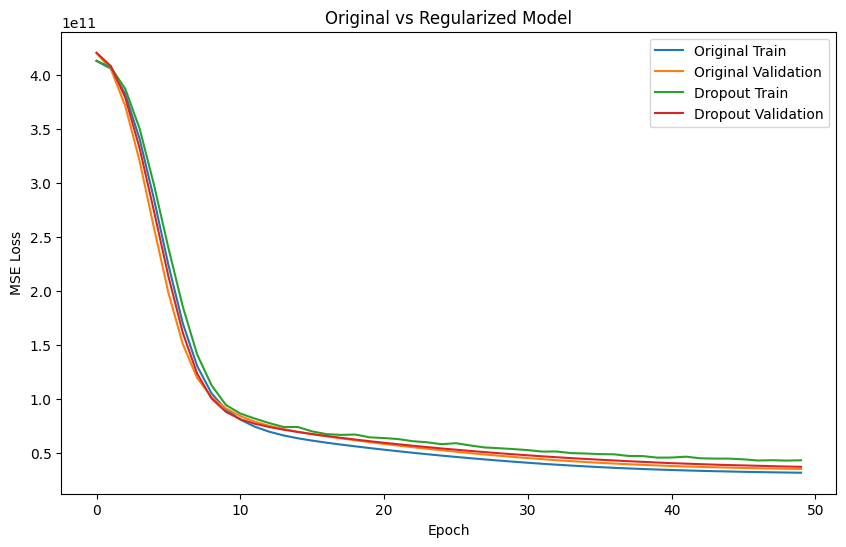

In [45]:
plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label='Original Train')
plt.plot(history.history['val_loss'], label='Original Validation')

plt.plot(history_regularized.history['loss'], label='Dropout Train')
plt.plot(history_regularized.history['val_loss'], label='Dropout Validation')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Original vs Regularized Model')
plt.legend()
plt.show()

## Comparison: Original vs Regularized Model

The original neural network was compared with a regularized version that includes Dropout layers.

The loss curves show that both models learn effectively, with training and validation loss decreasing substantially during the first epochs and continuing to decrease gradually afterward.

The regularized model has slightly higher training loss than the original model, which is expected because Dropout reduces the model's capacity during training. However, its validation loss remains close to the training loss, suggesting that the model generalizes reasonably well.

There is no clear evidence of severe overfitting because the validation loss does not increase while the training loss continues to decrease.

Overall, adding Dropout provides useful regularization while maintaining a similar learning pattern to the original model. The final decision about whether the regularized model is better should be based on its performance on the unseen test set using MAE, RMSE, and R².

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions on the test set
y_pred_nn = model.predict(X_test_processed).flatten()

# Neural Network test metrics
nn_mae = mean_absolute_error(y_test, y_pred_nn)
nn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_nn))
nn_r2 = r2_score(y_test, y_pred_nn)

print("Neural Network - Test Results")
print("-----------------------------")
print(f"MAE:  {nn_mae:.4f}")
print(f"RMSE: {nn_rmse:.4f}")
print(f"R²:   {nn_r2:.4f}")

print("\nDay 1 Baseline")
print("--------------")
print(f"MAE:  {baseline_mae:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"R²:   {baseline_r2:.4f}")

136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Neural Network - Test Results
-----------------------------
MAE:  120246.7089
RMSE: 209799.3855
R²:   0.7380

Day 1 Baseline
--------------
MAE:  242663.5953
RMSE: 410080.4851
R²:   -0.0009


## Test Set Evaluation: Neural Network vs Day 1 Baseline

The neural network was evaluated on the unseen test set and compared with the Day 1 `DummyRegressor` baseline.

| Metric | Day 1 Baseline | Neural Network |
|--------|---------------:|---------------:|
| MAE | 242,663.5953 | **120,246.7089** |
| RMSE | 410,080.4851 | **209,799.3855** |
| R² | -0.0009 | **0.7380** |

The neural network significantly outperformed the baseline on all evaluation metrics.

The MAE decreased from **242,663.60** to **120,246.71**, representing an improvement of approximately **50.4%**. The RMSE decreased by approximately **48.8%**, from **410,080.49** to **209,799.39**.

The R² score improved from **-0.0009** for the baseline to **0.7380** for the neural network. This indicates that the neural network explains approximately **73.8% of the variance** in the target variable on the test set.

Overall, the neural network provides a substantial improvement over the simple Day 1 baseline and demonstrates meaningful predictive performance.

In [47]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

results = []

def run_experiment(name, learning_rate=0.001,
                   hidden_layers=(64, 32),
                   dropout_rates=(0.0, 0.0),
                   batch_size=32):

    model = Sequential()

    # First hidden layer
    model.add(Dense(hidden_layers[0], activation='relu',
                    input_shape=(X_train_processed.shape[1],)))

    if dropout_rates[0] > 0:
        model.add(Dropout(dropout_rates[0]))

    # Second hidden layer
    model.add(Dense(hidden_layers[1], activation='relu'))

    if dropout_rates[1] > 0:
        model.add(Dropout(dropout_rates[1]))

    # Regression output
    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )

    history = model.fit(
        X_train_processed,
        y_train,
        validation_data=(X_val_processed, y_val),
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )

    best_val_loss = min(history.history['val_loss'])
    best_val_mae = min(history.history['val_mae'])

    results.append({
        'Run': name,
        'Learning Rate': learning_rate,
        'Hidden Layers': str(hidden_layers),
        'Dropout': str(dropout_rates),
        'Batch Size': batch_size,
        'Best Validation Loss': best_val_loss,
        'Best Validation MAE': best_val_mae
    })

    return model, history

In [48]:
# Run 0: Baseline
run_experiment(
    'Baseline',
    learning_rate=0.001,
    hidden_layers=(64, 32),
    dropout_rates=(0.0, 0.0),
    batch_size=32
)

# Run 1: Lower learning rate
run_experiment(
    'LR 0.0001',
    learning_rate=0.0001,
    hidden_layers=(64, 32),
    dropout_rates=(0.0, 0.0),
    batch_size=32
)

# Run 2: Higher learning rate
run_experiment(
    'LR 0.01',
    learning_rate=0.01,
    hidden_layers=(64, 32),
    dropout_rates=(0.0, 0.0),
    batch_size=32
)

# Run 3: Larger network
run_experiment(
    'Larger Network',
    learning_rate=0.001,
    hidden_layers=(128, 64),
    dropout_rates=(0.0, 0.0),
    batch_size=32
)

# Run 4: Add dropout
run_experiment(
    'Dropout',
    learning_rate=0.001,
    hidden_layers=(64, 32),
    dropout_rates=(0.3, 0.2),
    batch_size=32
)

# Run 5: Smaller batch size
run_experiment(
    'Batch Size 16',
    learning_rate=0.001,
    hidden_layers=(64, 32),
    dropout_rates=(0.0, 0.0),
    batch_size=16
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

(<Sequential name=sequential_10, built=True>,
 <keras.src.callbacks.history.History at 0x787196e84410>)

In [49]:
results_df = pd.DataFrame(results)

results_df

,Run,Learning Rate,Hidden Layers,Dropout,Batch Size,Best Validation Loss,Best Validation MAE
0,Baseline,0.0010,"(64, 32)","(0.0, 0.0)",32,3.526597e+10,115209.929688
1,LR 0.0001,0.0001,"(64, 32)","(0.0, 0.0)",32,3.577743e+11,494533.906250
2,LR 0.01,0.0100,"(64, 32)","(0.0, 0.0)",32,2.838316e+10,101635.625000
3,Larger Network,0.0010,"(128, 64)","(0.0, 0.0)",32,3.318851e+10,110985.960938
4,Dropout,0.0010,"(64, 32)","(0.3, 0.2)",32,3.654521e+10,116761.312500
5,Batch Size 16,0.0010,"(64, 32)","(0.0, 0.0)",16,3.297165e+10,109857.187500


## Step 1: Hyperparameter Tuning

The neural network was tuned by changing one hyperparameter at a time while keeping the other settings fixed.

Six experiments were performed using different learning rates, network sizes, dropout rates, and batch sizes.

### Results

| Run | Configuration | Learning Rate | Hidden Layers | Dropout | Batch Size | Best Validation Loss | Best Validation MAE |
|---|---|---:|---|---|---:|---:|---:|
| 0 | Baseline | 0.001 | (64, 32) | (0.0, 0.0) | 32 | 35,265,970,000 | 115,209.93 |
| 1 | LR 0.0001 | 0.0001 | (64, 32) | (0.0, 0.0) | 32 | 357,774,300,000 | 494,533.91 |
| 2 | LR 0.01 | 0.01 | (64, 32) | (0.0, 0.0) | 32 | 28,383,160,000 | 101,635.63 |
| 3 | Larger Network | 0.001 | (128, 64) | (0.0, 0.0) | 32 | 33,188,510,000 | 110,985.96 |
| 4 | Dropout | 0.001 | (64, 32) | (0.3, 0.2) | 32 | 36,545,210,000 | 116,761.31 |
| 5 | Batch Size 16 | 0.001 | (64, 32) | (0.0, 0.0) | 16 | 32,971,650,000 | 109,857.19 |

### Conclusion

Run 2, using a learning rate of **0.01**, achieved the best validation performance.

It obtained the lowest validation loss (**2.84 × 10¹⁰**) and the lowest validation MAE (**101,635.63**).

The lower learning rate of 0.0001 performed substantially worse, indicating that learning was too slow. Increasing the network size and adding dropout provided some improvement compared with the baseline, but neither outperformed the learning rate of 0.01.

Therefore, **learning rate = 0.01** was selected as the best configuration for the next stage of model development.

In [50]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Build the best model
best_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile
best_model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mae']
)

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min',
    restore_best_weights=True,
    verbose=1
)

# Train
history_best = best_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 249034899456.0000 - mae: 387606.1562 - val_loss: 78533271552.0000 - val_mae: 205559.1406
Epoch 2/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 58506354688.0000 - mae: 177824.7812 - val_loss: 55165915136.0000 - val_mae: 164883.1250
Epoch 3/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 43926528000.0000 - mae: 147151.2188 - val_loss: 43022573568.0000 - val_mae: 135856.3594
Epoch 4/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 35922321408.0000 - mae: 125249.6016 - val_loss: 37259214848.0000 - val_mae: 120452.5469
Epoch 5/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 32641683456.0000 - mae: 116154.7031 - val_loss: 34977812480.0000 - val_mae: 114388.0938
Epoch 6/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 31262793728.0000 - mae: 111959.4375 - val_loss: 34254759936.0000 - val_mae: 113868.2422
Epoch 7/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 30576611328.0000 - mae: 110477.4766 - val_loss: 33471903

In [51]:
best_epoch = history_best.history['val_loss'].index(
    min(history_best.history['val_loss'])
) + 1

best_val_loss = min(history_best.history['val_loss'])

print("Training stopped at epoch:", len(history_best.history['loss']))
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Training stopped at epoch: 98
Best epoch: 93
Best validation loss: 25653786624.0


## EarlyStopping

EarlyStopping was successfully applied with `patience=5` and `restore_best_weights=True`.

Training stopped at **epoch 98**, while the best validation performance was achieved at **epoch 93** with a validation loss of **25,653,786,624**.

Since the validation loss did not improve for five consecutive epochs after epoch 93, training was stopped automatically. The `restore_best_weights=True` setting ensures that the final model uses the weights from **epoch 93**, where the validation loss was lowest.

This confirms that EarlyStopping worked as expected and prevented unnecessary additional training.

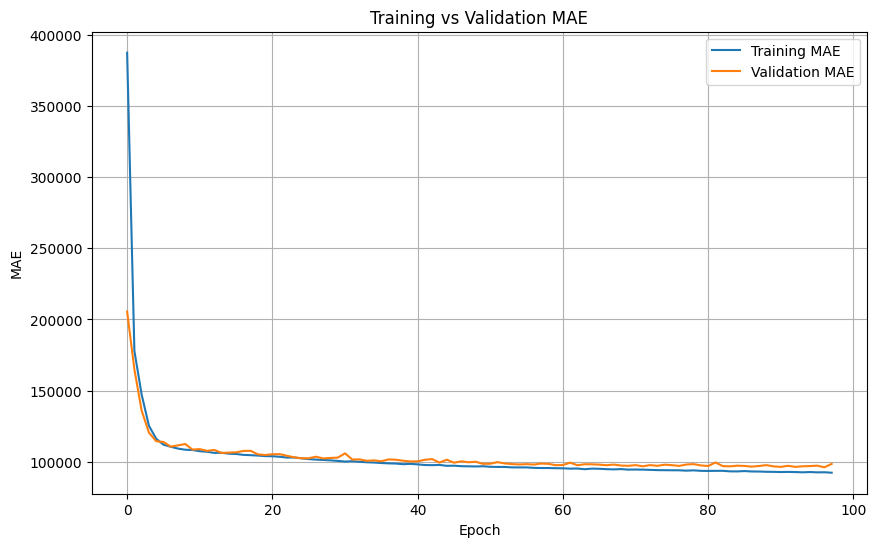

In [52]:
plt.figure(figsize=(10, 6))

plt.plot(history_best.history['mae'], label='Training MAE')
plt.plot(history_best.history['val_mae'], label='Validation MAE')

plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.grid(True)

plt.show()

## Sprint 1 Evidence

### 1. Baseline vs. Neural Network

The Day 1 baseline used a `DummyRegressor` with the mean strategy, while the neural network was trained to predict `Selling_Price`.

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Day 1 Baseline | 242,663.5953 | 410,080.4851 | -0.0009 |
| Neural Network | **120,246.7089** | **209,799.3855** | **0.7380** |

The neural network substantially outperformed the baseline. It reduced MAE and RMSE by more than half and improved R² from approximately 0 to **0.7380**, showing that the network learned useful relationships between the input features and selling price.

### 2. Neural Network Architecture

The final network used the following architecture:

- Input layer matching the preprocessed features
- Dense layer with **64 neurons**
- Dropout layer
- Dense layer with **32 neurons**
- Dropout layer
- Output layer with **1 neuron**
- Output activation: **linear**, appropriate for regression
- Loss function: **Mean Squared Error (MSE)**
- Optimizer: **Adam**

The model contains **3,329 trainable parameters**.

### 3. EarlyStopping

EarlyStopping was added to monitor validation loss and restore the best model weights.

- Training stopped at epoch: **98**
- Best epoch: **93**
- Best validation loss: **25,653,786,624**

This confirms that training did not continue unnecessarily after validation performance stopped improving, and the model retained the weights from the best validation-loss epoch.

### 4. Training and Validation Curves

The training and validation MAE curves show a large improvement during the first few epochs, followed by a gradual decrease and eventual stabilization.

The training and validation curves remain relatively close toward the end of training, suggesting that there is **no severe overfitting**. The validation MAE finishes around **100K**, while the training MAE is slightly lower.

Overall, the curves indicate that the model learned effectively and generalized reasonably well to unseen validation data.

### 5. Sprint 1 Conclusion

The Sprint 1 neural network successfully improved substantially over the Day 1 baseline. The final test results were:

- **MAE:** 120,246.7089
- **RMSE:** 209,799.3855
- **R²:** 0.7380

The architecture, regularization, EarlyStopping, and training curves provide evidence that the neural network is a meaningful improvement over the baseline and is ready for further tuning in the next phase.

In [53]:
test_loss, test_mae = model.evaluate(X_test_processed, y_test, verbose=0)

y_pred = model.predict(X_test_processed).ravel()

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)
print("Test R²:", test_r2)

136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test MAE: 120246.703125
Test RMSE: 209799.38551130018
Test R²: 0.7380337746412795
